# Temporal Prediction of Surface Protein Abundance from Single-cell RNA

**NeurIPS 2022 Open Problems in Multimodal Learning — CITE-seq task**

This notebook presents the final comparison of a mean-profile baseline,
Ridge regression and a multi-output neural network for predicting 140
surface proteins from single-cell RNA expression.

The central question is whether models trained on observed collection
days can generalize to an unseen time point.

## 1. Study design

The aligned CITE-seq dataset contains 70,988 cells with paired RNA and
surface-protein measurements:

- **RNA input:** 22,050 gene-expression features
- **Prediction targets:** 140 surface proteins
- **Training set:** 42,843 cells from Day 2 and Day 3
- **Temporal validation set:** 28,145 cells from Day 4

A time-based split was used instead of a random cell split. This provides
a more realistic test of temporal generalization during cell
differentiation.

To reduce dimensionality, RNA expression was projected onto 50 principal
components. PCA was fitted only on Day 2–3 cells and then applied to Day 4
cells, preventing information leakage from the evaluation time point.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path) -> Path:
    """Find the project root from either the root or notebooks directory."""

    candidates = [start, *start.parents]

    for candidate in candidates:
        if (
            (candidate / "configs").exists()
            and (candidate / "results").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. "
        "Open this notebook inside single_cell_protein_prediction."
    )


ROOT = find_project_root(Path.cwd().resolve())
RESULTS_DIR = ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"

print("Project root:", ROOT)
print("Results directory:", RESULTS_DIR)

Project root: /mnt/ssd/caoying/open-problems-multimodal/single_cell_protein_prediction
Results directory: /mnt/ssd/caoying/open-problems-multimodal/single_cell_protein_prediction/results


In [2]:
required_files = [
    ROOT / "data" / "processed" / "cite_day_split_pca.npz",
    RESULTS_DIR / "EXP00_mean_profile" / "metrics_summary.json",
    RESULTS_DIR / "EXP01_pca50_ridge" / "metrics_summary.json",
    RESULTS_DIR
    / "EXP02_pca50_multioutput_mlp"
    / "metrics_summary.json",
]

file_check = pd.DataFrame(
    {
        "file": [
            str(path.relative_to(ROOT))
            for path in required_files
        ],
        "exists": [
            path.exists()
            for path in required_files
        ],
    }
)

display(file_check)

if not file_check["exists"].all():
    missing = file_check.loc[
        ~file_check["exists"],
        "file",
    ].tolist()

    raise FileNotFoundError(
        f"Missing required files: {missing}"
    )

,file,exists
0,data/processed/cite_day_split_pca.npz,True
1,results/EXP00_mean_profile/metrics_summary.json,True
2,results/EXP01_pca50_ridge/metrics_summary.json,True
3,results/EXP02_pca50_multioutput_mlp/metrics_su...,True


In [3]:
prepared_path = (
    ROOT
    / "data"
    / "processed"
    / "cite_day_split_pca.npz"
)

with np.load(prepared_path, allow_pickle=True) as prepared:
    data_shapes = pd.DataFrame(
        {
            "Array": [
                "X_train",
                "X_validation",
                "y_train",
                "y_validation",
            ],
            "Shape": [
                str(prepared["X_train"].shape),
                str(prepared["X_validation"].shape),
                str(prepared["y_train"].shape),
                str(prepared["y_validation"].shape),
            ],
            "Description": [
                "Day 2–3 RNA PCA features",
                "Day 4 RNA PCA features",
                "Day 2–3 protein targets",
                "Day 4 protein targets",
            ],
        }
    )

display(data_shapes)

,Array,Shape,Description
0,X_train,"(42843, 50)",Day 2–3 RNA PCA features
1,X_validation,"(28145, 50)",Day 4 RNA PCA features
2,y_train,"(42843, 140)",Day 2–3 protein targets
3,y_validation,"(28145, 140)",Day 4 protein targets


## 2. Prediction models

### Mean-profile baseline

The mean protein profile of the Day 2–3 training cells was assigned to
every Day 4 cell. This is the optimal constant predictor under squared
error loss and measures how much performance can be achieved from the
shared average protein profile alone.

### Ridge regression

A multi-output Ridge regression model was fitted using the 50
standardized PCA features. Ridge was selected as a strong linear model
because it is computationally efficient, regularized and interpretable.

### Multi-output MLP

A neural network with architecture **50–64–32–140** was trained to
predict all 140 proteins simultaneously. It used ReLU activations,
dropout regularization and an internal Day 2–3 validation split for
training diagnostics.

Ridge and MLP used the same input features and the same Day 2–3/Day 4
temporal evaluation design.

## 3. Evaluation metrics

The primary metric is the competition-style mean row-wise Pearson
correlation. For each cell, Pearson correlation is calculated across the
140 predicted and observed proteins, and these correlations are then
averaged across cells.

Two complementary metrics are also reported:

- **Protein-wise PCC:** correlation across Day 4 cells for each protein
- **RMSE:** absolute error in predicted protein abundance

Row-wise Pearson measures whether the relative protein profile of each
cell is reconstructed correctly. Protein-wise PCC evaluates whether the
model captures cell-to-cell variation in individual proteins.

In [4]:
figure_jobs = [
    (
        "make_model_comparison.py",
        "figure1_model_comparison.png",
    ),
    (
        "make_per_protein_comparison.py",
        "figure2_ridge_mlp_per_protein_pcc.png",
    ),
    (
        "make_mlp_loss_curve.py",
        "figure3_mlp_training_curve.png",
    ),
    (
        "analyze_ridge_coefficients.py",
        "figure4_ridge_pca_coefficients.png",
    ),
]

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for script_name, figure_name in figure_jobs:
    figure_path = FIGURE_DIR / figure_name

    if not figure_path.exists():
        print(f"Generating {figure_name}...")

        subprocess.run(
            [
                sys.executable,
                str(ROOT / "scripts" / script_name),
            ],
            cwd=ROOT,
            check=True,
        )

print("All report figures are available.")

All report figures are available.


In [5]:
comparison_path = (
    RESULTS_DIR / "model_comparison.csv"
)

comparison = pd.read_csv(comparison_path)

metric_columns = [
    "model",
    "rowwise_pearson",
    "mean_proteinwise_pcc",
    "median_proteinwise_pcc",
    "rmse",
]

display(
    comparison[metric_columns]
    .rename(
        columns={
            "model": "Model",
            "rowwise_pearson": "Row-wise Pearson",
            "mean_proteinwise_pcc": "Mean protein PCC",
            "median_proteinwise_pcc": "Median protein PCC",
            "rmse": "RMSE",
        }
    )
    .round(4)
    .style
    .format(
        {
            "Row-wise Pearson": "{:.4f}",
            "Mean protein PCC": "{:.4f}",
            "Median protein PCC": "{:.4f}",
            "RMSE": "{:.4f}",
        },
        na_rep="Undefined",
    )
    .highlight_min(
        subset=["RMSE"],
        color="#d9ead3",
    )
    .highlight_max(
        subset=[
            "Row-wise Pearson",
            "Mean protein PCC",
            "Median protein PCC",
        ],
        color="#d9ead3",
    )
)

,Model,Row-wise Pearson,Mean protein PCC,Median protein PCC,RMSE
0,Mean-profile,0.7776,Undefined,Undefined,2.2916
1,Ridge,0.8755,0.4088,0.3922,1.6815
2,Multi-output MLP,0.8727,0.4084,0.3948,1.7076


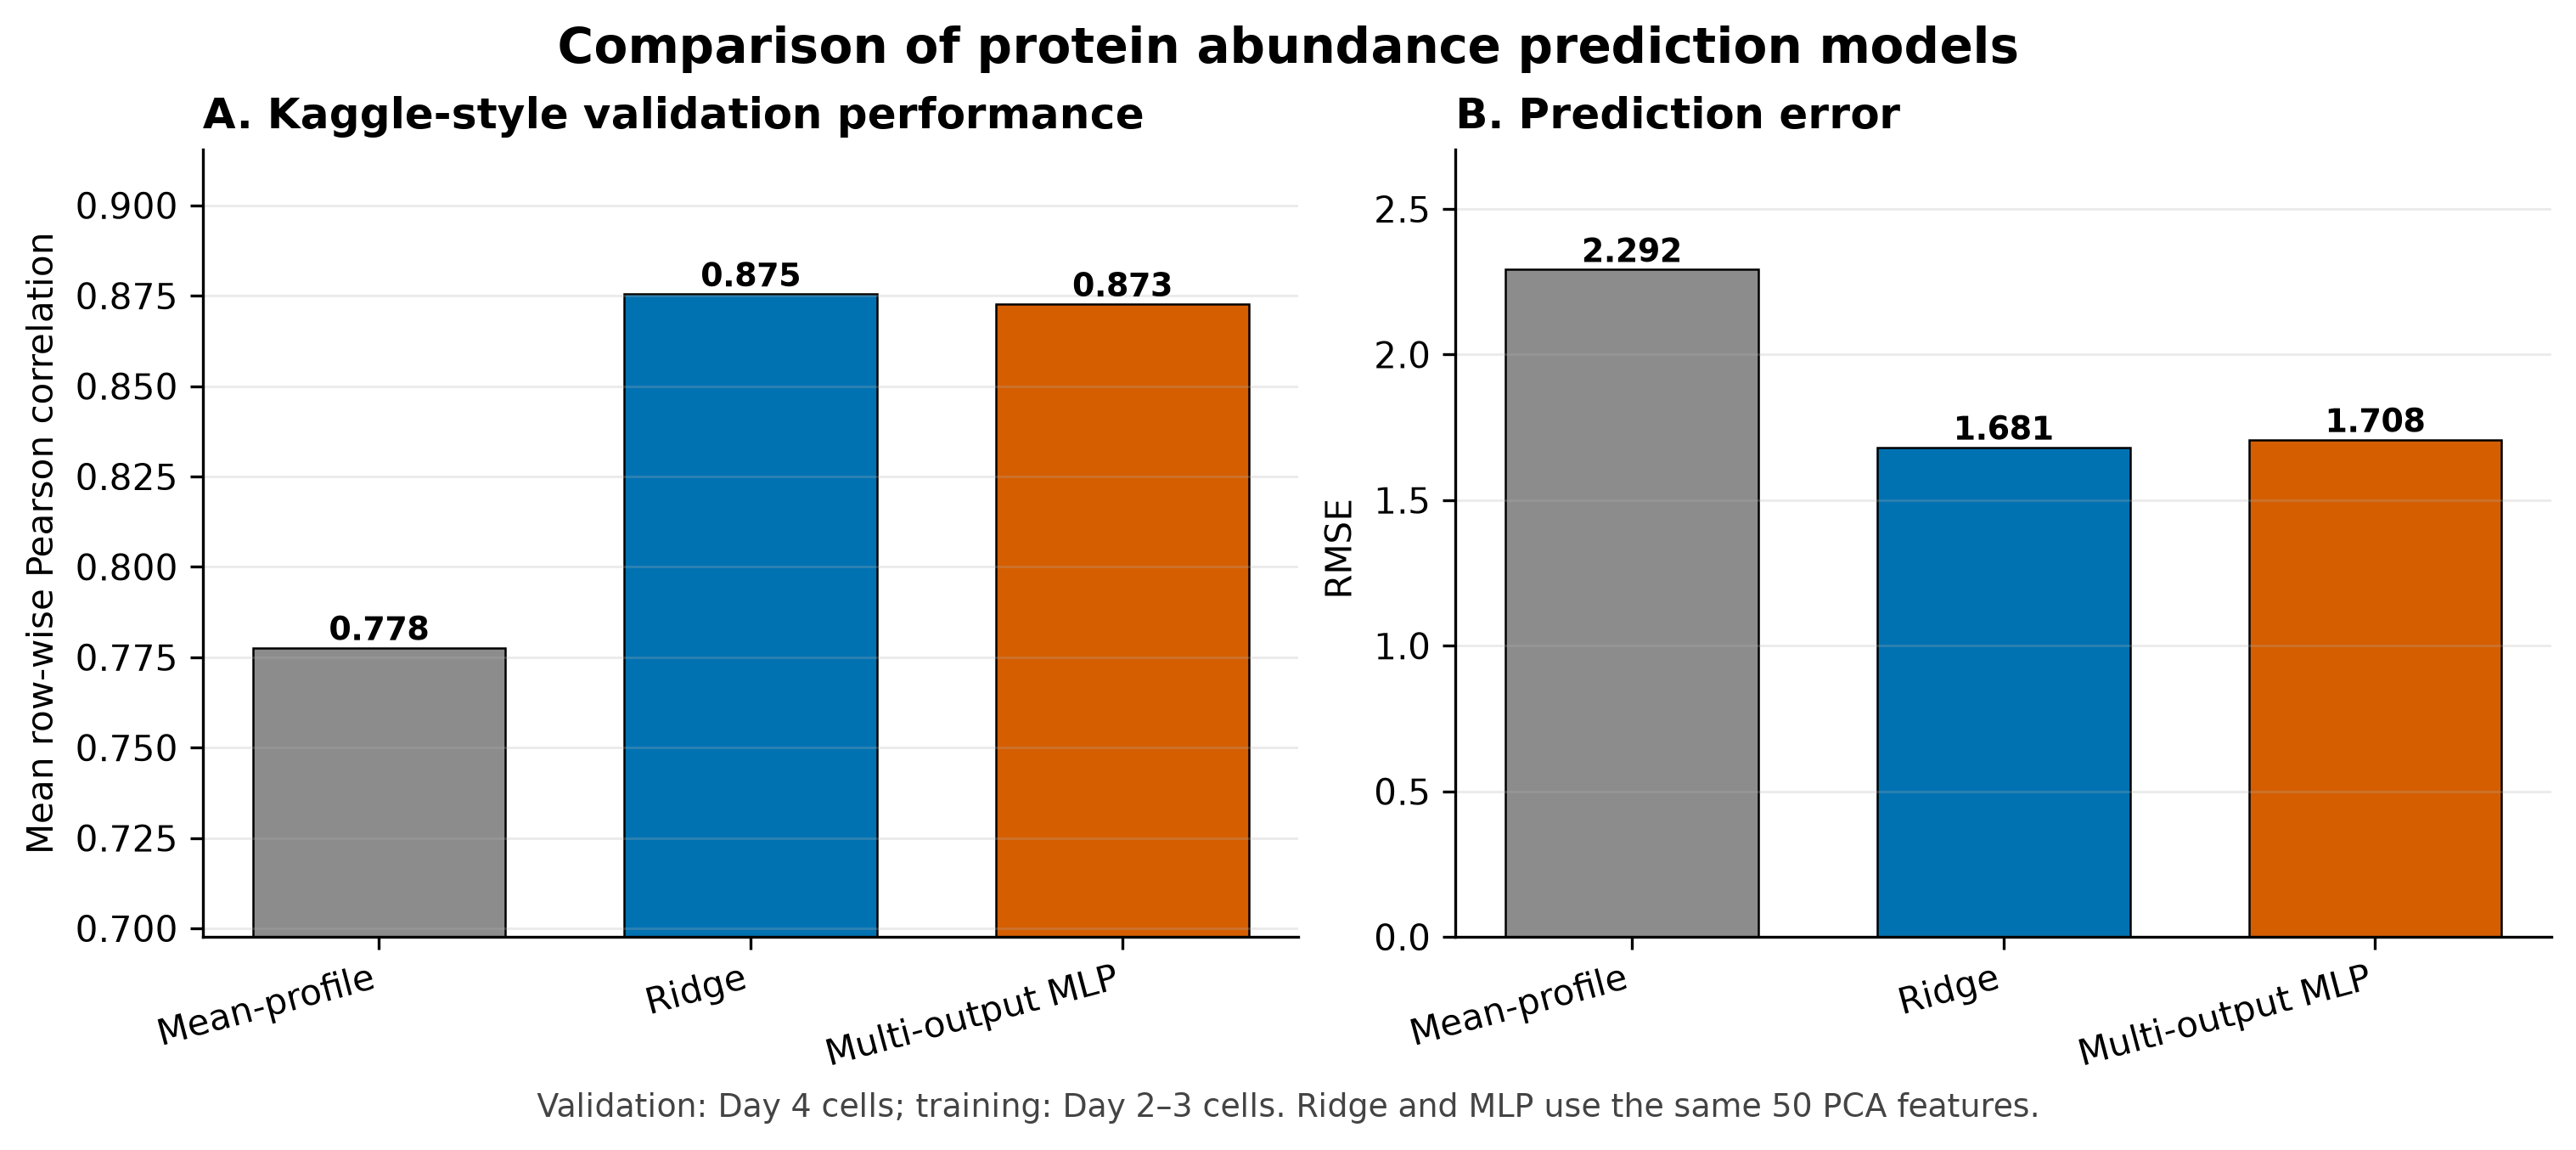

In [6]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "figure1_model_comparison.png"
        ),
        width=950,
    )
)

In [7]:
baseline = comparison.loc[
    comparison["model"] == "Mean-profile"
].iloc[0]

ridge = comparison.loc[
    comparison["model"] == "Ridge"
].iloc[0]

mlp = comparison.loc[
    comparison["model"] == "Multi-output MLP"
].iloc[0]

ridge_rmse_reduction = (
    baseline["rmse"] - ridge["rmse"]
) / baseline["rmse"] * 100

mlp_rmse_reduction = (
    baseline["rmse"] - mlp["rmse"]
) / baseline["rmse"] * 100

display(
    Markdown(
        f"""
### Main results

Both learned models substantially outperformed the mean-profile
baseline on the unseen Day 4 cells.

- Ridge increased row-wise Pearson from
  **{baseline["rowwise_pearson"]:.4f}** to
  **{ridge["rowwise_pearson"]:.4f}** and reduced RMSE by
  **{ridge_rmse_reduction:.1f}%**.
- The MLP achieved the highest row-wise Pearson,
  **{mlp["rowwise_pearson"]:.4f}**, but its advantage over Ridge was only
  **{mlp["rowwise_pearson"] - ridge["rowwise_pearson"]:.4f}**.
- Ridge achieved the lowest RMSE
  (**{ridge["rmse"]:.4f}** versus **{mlp["rmse"]:.4f}** for the MLP).
- Mean protein-wise PCC was nearly identical for Ridge and MLP.

The small performance difference indicates that the 50-dimensional RNA
representation contains a strong linear predictive signal, and that the
additional nonlinear complexity of the MLP did not provide a clear
overall advantage.
"""
    )
)


### Main results

Both learned models substantially outperformed the mean-profile
baseline on the unseen Day 4 cells.

- Ridge increased row-wise Pearson from
  **0.7776** to
  **0.8755** and reduced RMSE by
  **26.6%**.
- The MLP achieved the highest row-wise Pearson,
  **0.8727**, but its advantage over Ridge was only
  **-0.0028**.
- Ridge achieved the lowest RMSE
  (**1.6815** versus **1.7076** for the MLP).
- Mean protein-wise PCC was nearly identical for Ridge and MLP.

The small performance difference indicates that the 50-dimensional RNA
representation contains a strong linear predictive signal, and that the
additional nonlinear complexity of the MLP did not provide a clear
overall advantage.


## 4. Protein-level model comparison

The official row-wise score does not show whether one model consistently
performs better across individual proteins. We therefore compared Ridge
and MLP PCC values for all 140 protein targets.

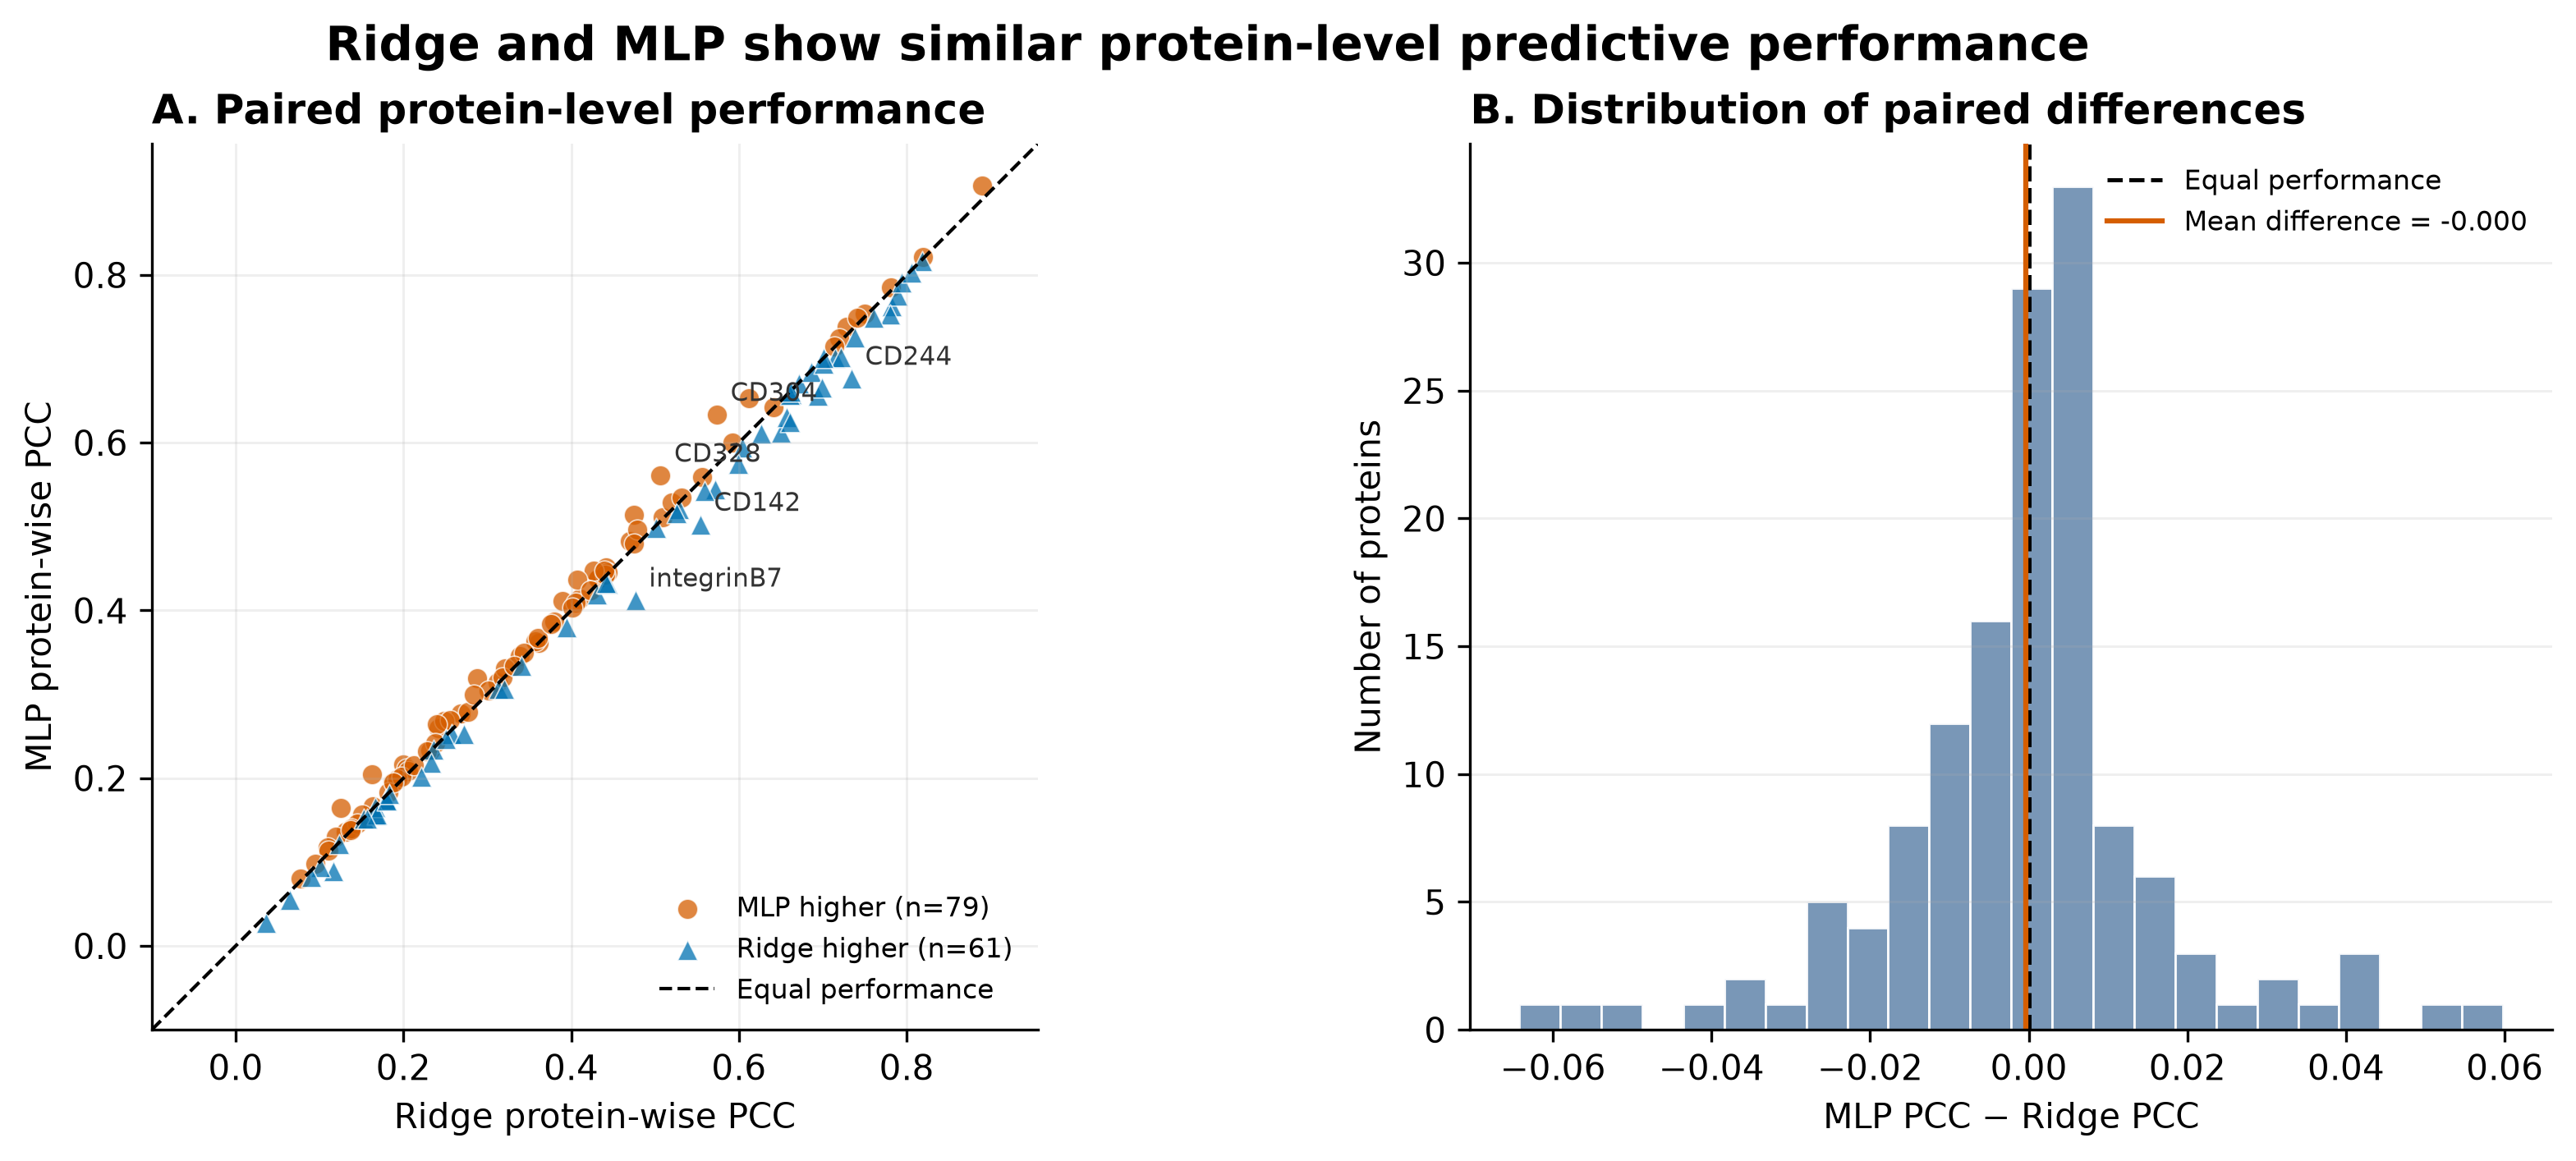

In [8]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "figure2_ridge_mlp_per_protein_pcc.png"
        ),
        width=1050,
    )
)

In [9]:
paired_path = (
    RESULTS_DIR
    / "ridge_mlp_per_protein_comparison.csv"
)

paired = pd.read_csv(paired_path)

ridge_wins = (
    paired["pcc_difference"] < 0
).sum()

mlp_wins = (
    paired["pcc_difference"] > 0
).sum()

mean_difference = paired[
    "pcc_difference"
].mean()

median_difference = paired[
    "pcc_difference"
].median()

display(
    Markdown(
        f"""
Ridge achieved a higher protein-wise PCC for **{ridge_wins}** proteins,
whereas MLP achieved a higher PCC for **{mlp_wins}** proteins.

The mean paired difference, defined as MLP PCC minus Ridge PCC, was
**{mean_difference:.4f}**, and the median difference was
**{median_difference:.4f}**. A difference distribution centered close
to zero supports the conclusion that neither model consistently
dominated across protein targets.
"""
    )
)


Ridge achieved a higher protein-wise PCC for **61** proteins,
whereas MLP achieved a higher PCC for **79** proteins.

The mean paired difference, defined as MLP PCC minus Ridge PCC, was
**-0.0004**, and the median difference was
**0.0016**. A difference distribution centered close
to zero supports the conclusion that neither model consistently
dominated across protein targets.


## 5. MLP training dynamics

Training and internal-validation losses were monitored using only the
Day 2–3 data. The internal-validation set used here is distinct from the
held-out Day 4 temporal validation set.

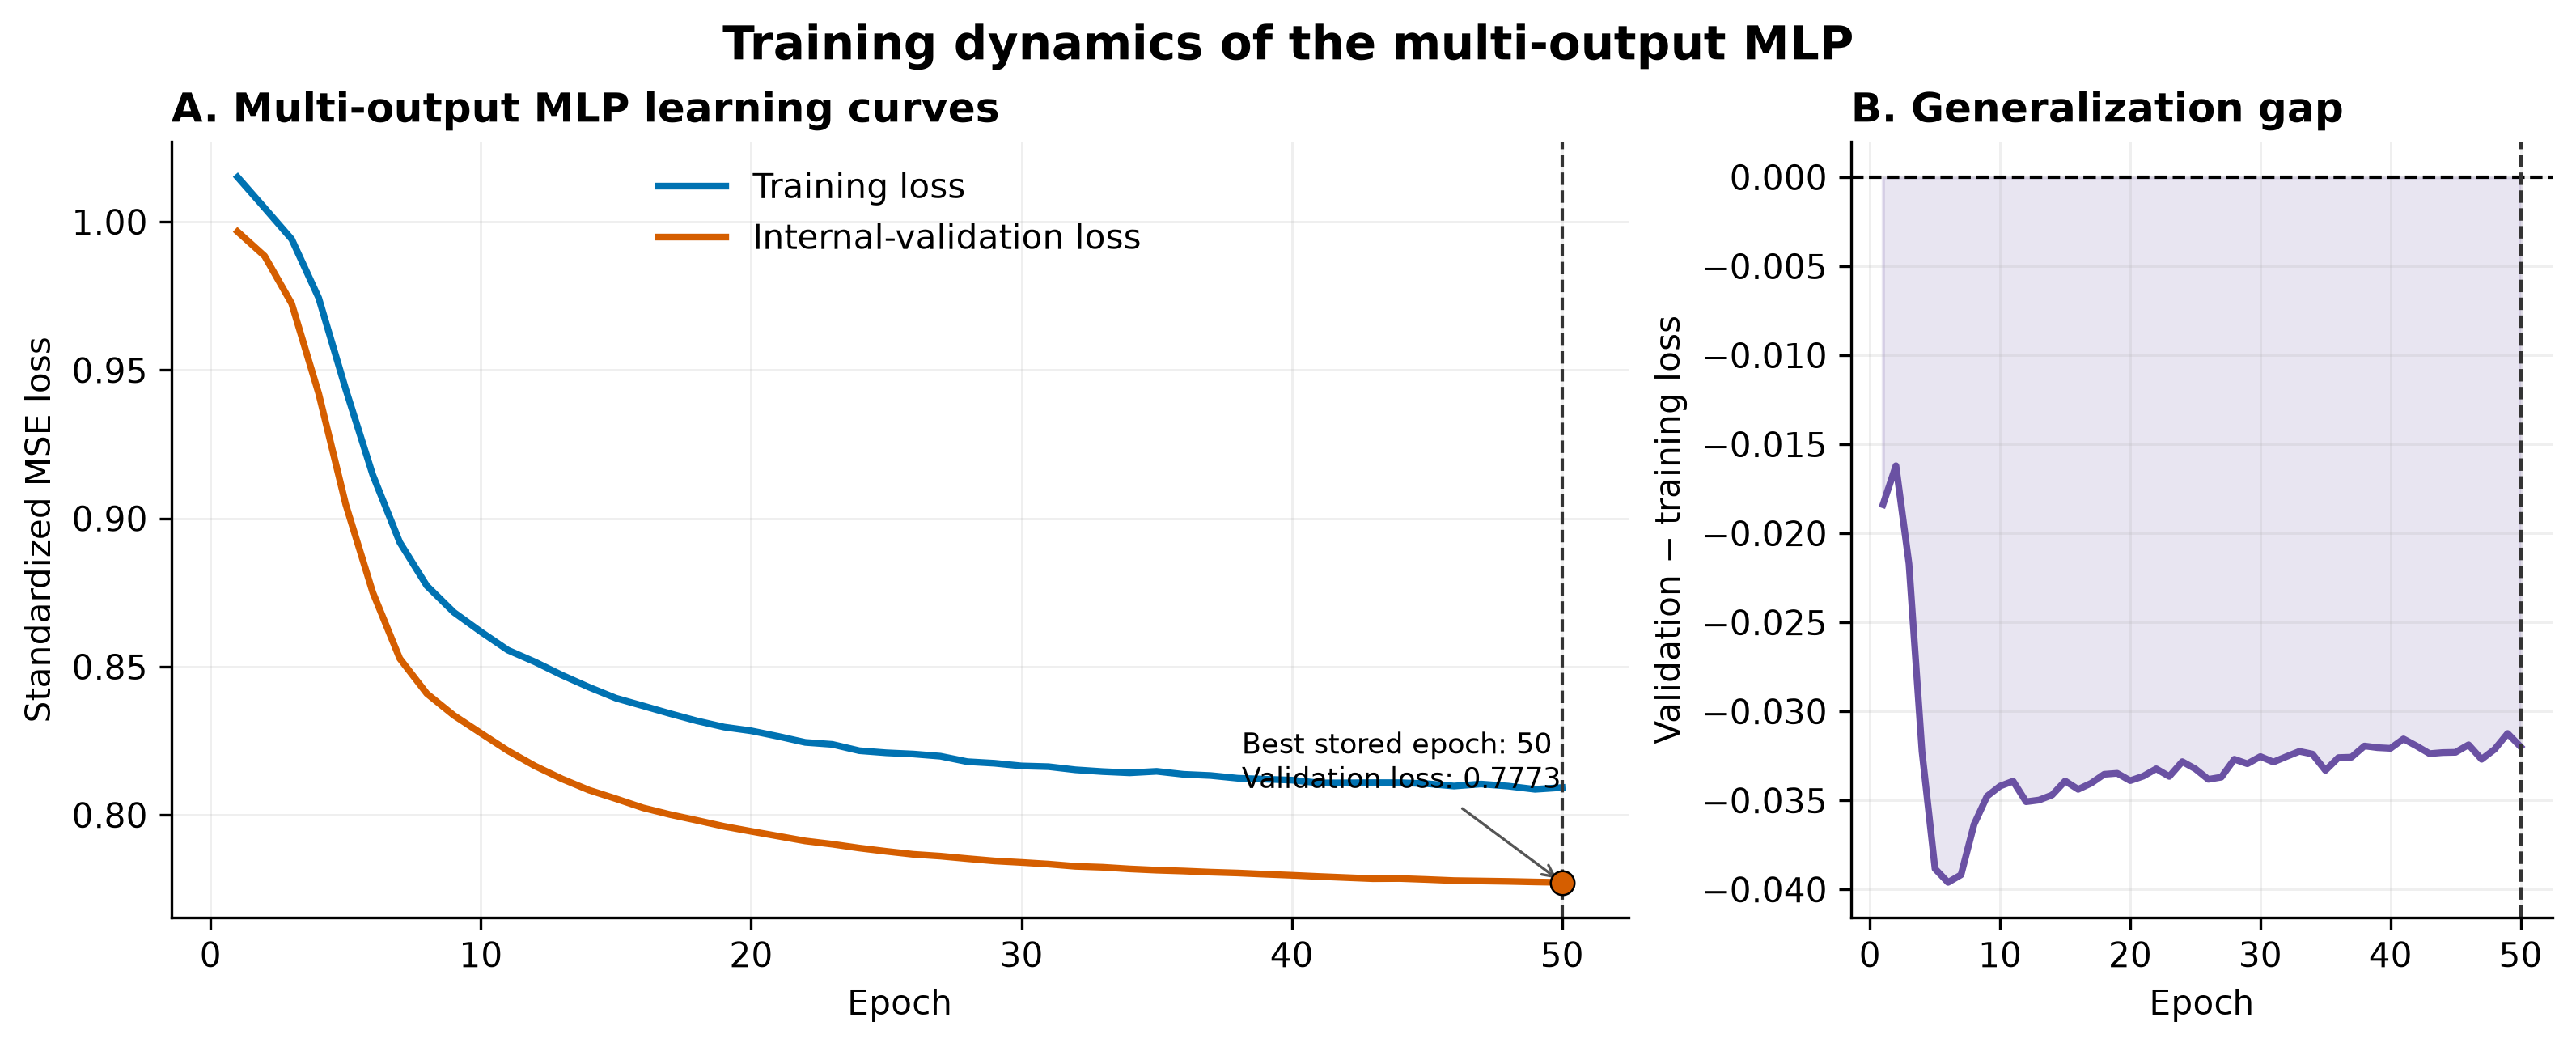

In [10]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "figure3_mlp_training_curve.png"
        ),
        width=1000,
    )
)

In [11]:
history_path = (
    RESULTS_DIR
    / "EXP02_pca50_multioutput_mlp"
    / "training_history.csv"
)

history = pd.read_csv(history_path)

validation_candidates = [
    "internal_validation_loss",
    "internal_val_loss",
    "validation_loss",
    "val_loss",
]

validation_column = next(
    column
    for column in validation_candidates
    if column in history.columns
)

best_index = history[
    validation_column
].idxmin()

best_epoch = int(
    history.loc[best_index, "epoch"]
)

maximum_epoch = int(
    history["epoch"].max()
)

if best_epoch == maximum_epoch:
    convergence_text = (
        "The lowest internal-validation loss occurred at "
        f"epoch {best_epoch}, which was also the maximum permitted "
        "epoch. Training was therefore stopped by the fixed epoch "
        "budget rather than by early stopping."
    )
else:
    convergence_text = (
        f"The lowest internal-validation loss occurred at epoch "
        f"{best_epoch}, before the maximum epoch of {maximum_epoch}."
    )

display(
    Markdown(
        f"""
{convergence_text}

The validation loss remained slightly below the training loss. This is
expected because dropout was active during training but disabled during
evaluation. The curves provide no clear evidence of severe overfitting.
The MLP is therefore treated as a **fixed-compute nonlinear baseline**,
rather than a fully optimized neural-network model.
"""
    )
)


The lowest internal-validation loss occurred at epoch 50, which was also the maximum permitted epoch. Training was therefore stopped by the fixed epoch budget rather than by early stopping.

The validation loss remained slightly below the training loss. This is
expected because dropout was active during training but disabled during
evaluation. The curves provide no clear evidence of severe overfitting.
The MLP is therefore treated as a **fixed-compute nonlinear baseline**,
rather than a fully optimized neural-network model.


## 6. Ridge coefficient interpretation

Because the PCA features were standardized before Ridge regression,
coefficient magnitudes can be compared across components. Global
importance was summarized using the mean absolute coefficient across all
140 protein targets.

PCA components represent multigene expression programs. Their Ridge
coefficients should therefore not be interpreted as direct gene-level
regulatory effects.

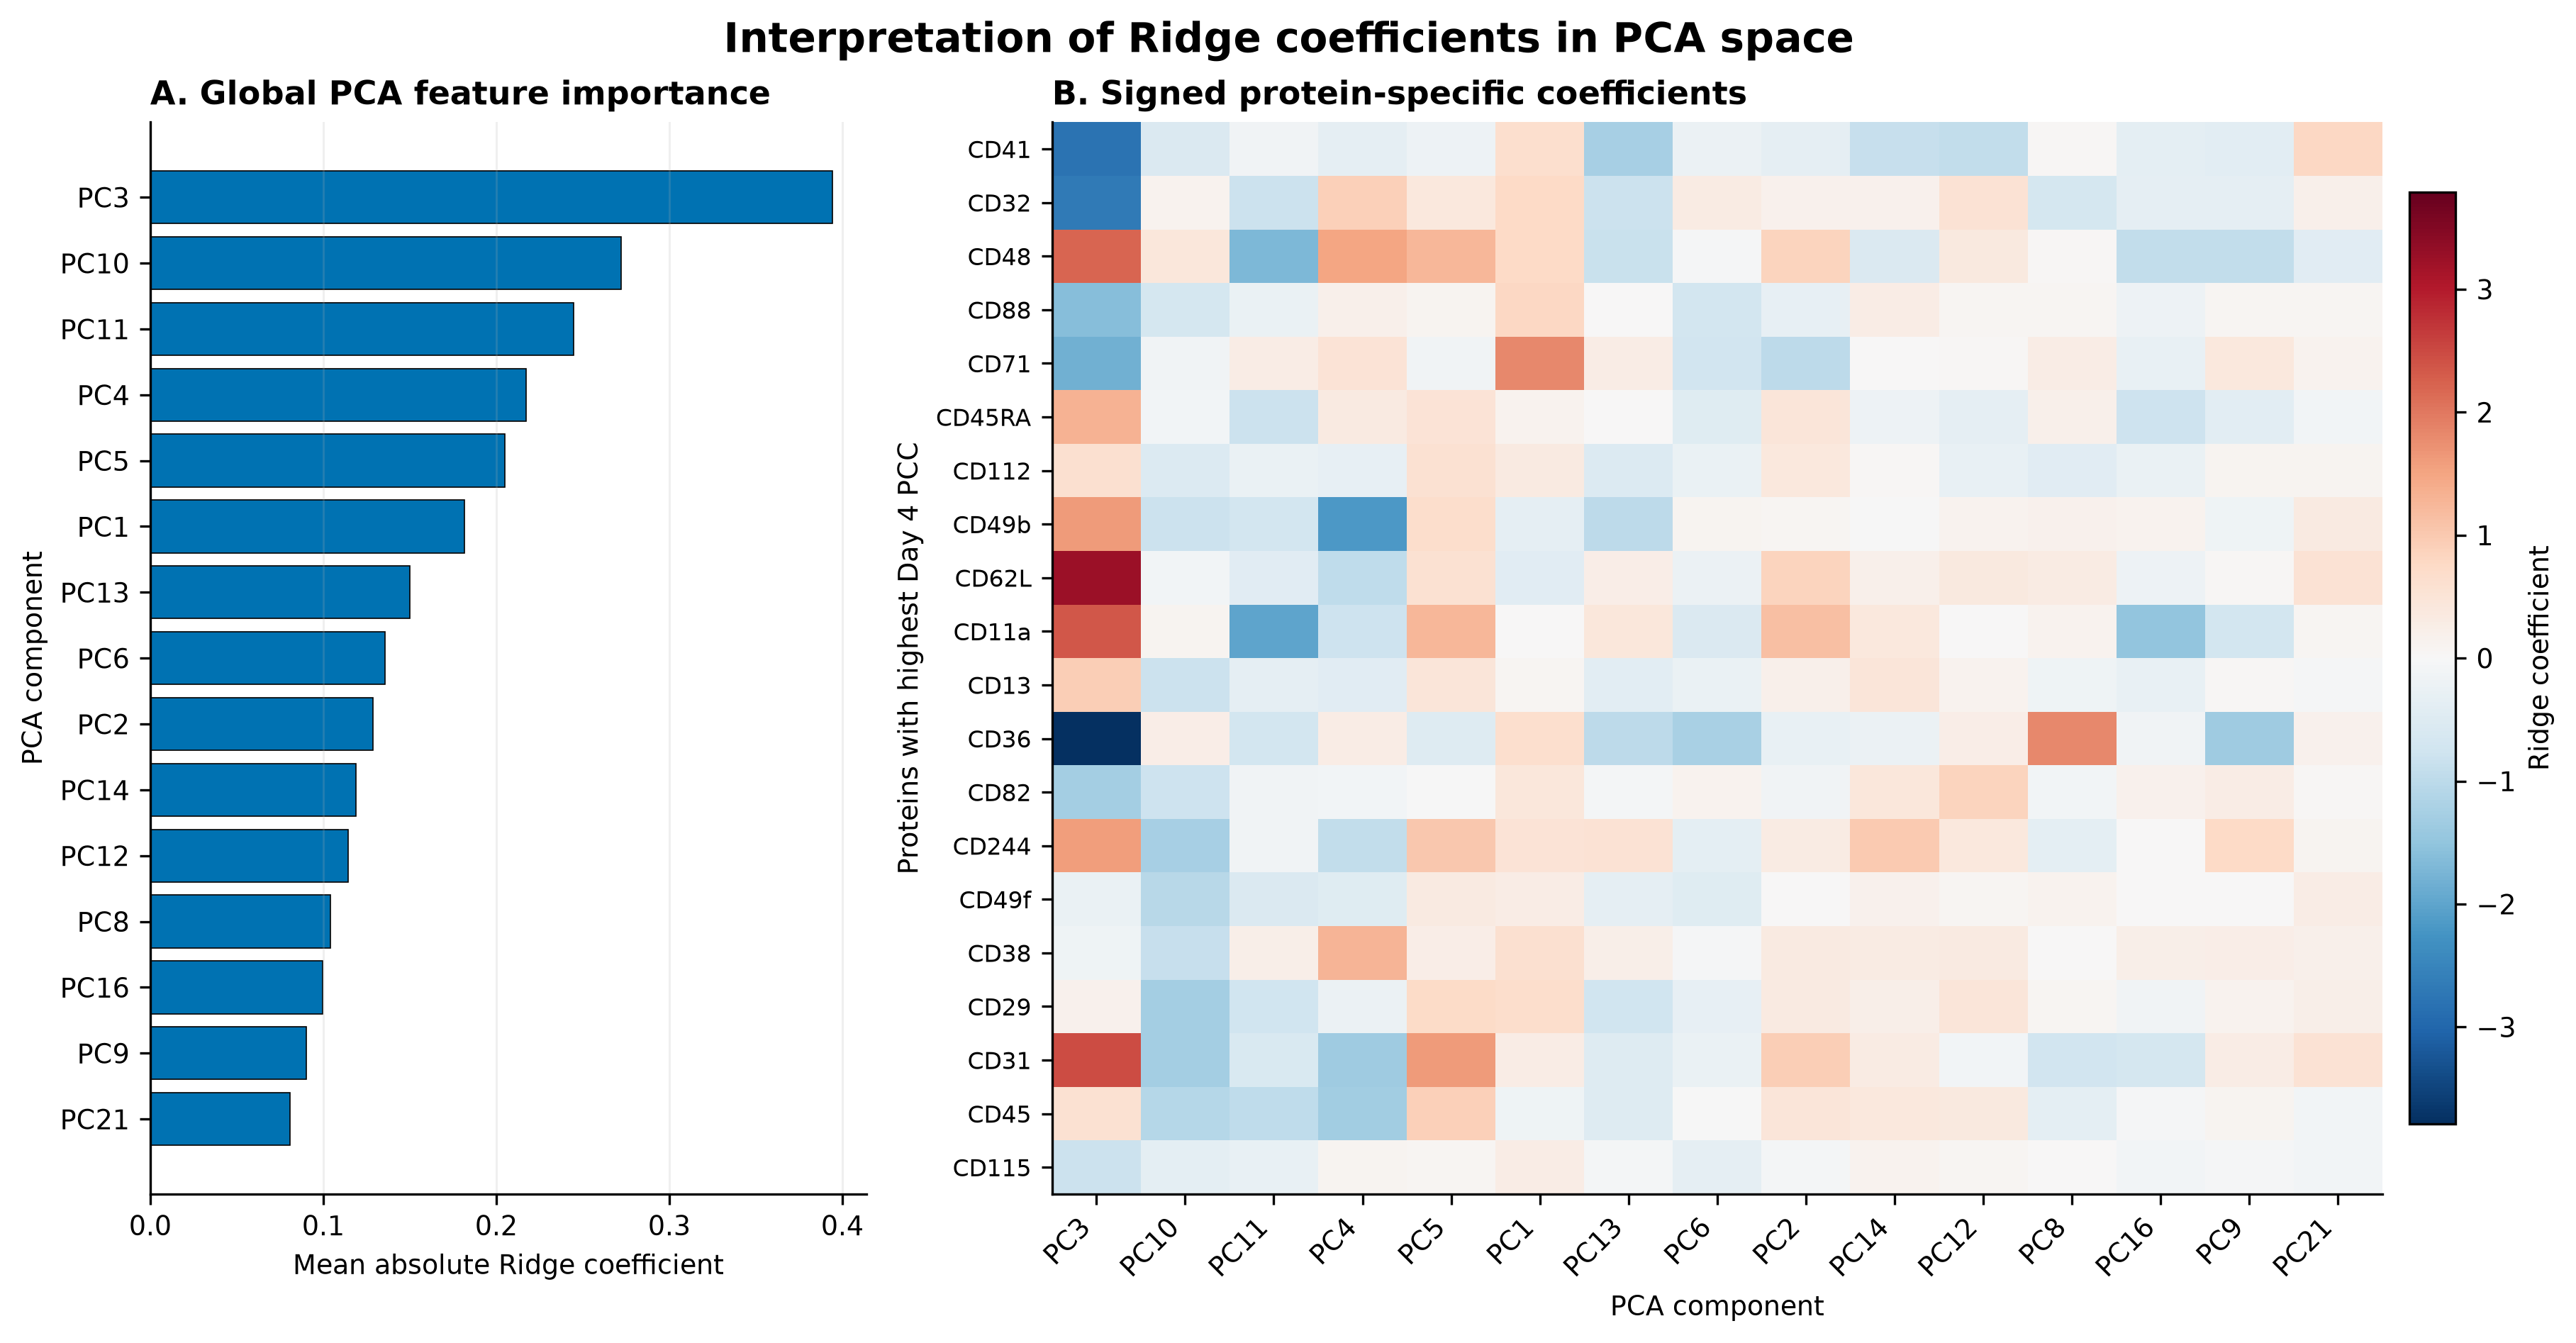

In [12]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "figure4_ridge_pca_coefficients.png"
        ),
        width=1100,
    )
)

In [13]:
importance_path = (
    RESULTS_DIR
    / "EXP01_pca50_ridge"
    / "ridge_pca_importance_analysis.csv"
)

importance = pd.read_csv(importance_path)

display(
    importance.head(15)
    .round(5)
    .style
    .background_gradient(
        subset=["mean_absolute_coefficient"],
        cmap="Blues",
    )
)

,PC,mean_absolute_coefficient,median_absolute_coefficient,coefficient_l2_norm
0,PC3,0.394330,0.125340,9.304480
1,PC10,0.272140,0.150630,4.743820
2,PC11,0.244820,0.124170,4.585720
3,PC4,0.217170,0.040370,5.399180
4,PC5,0.205110,0.068750,4.415920
5,PC1,0.181640,0.059260,4.221720
6,PC13,0.150020,0.050690,3.188000
7,PC6,0.135860,0.082320,2.534070
8,PC2,0.128890,0.031720,2.984180
9,PC14,0.118770,0.063080,2.298000


## 7. Limitations

Several limitations should be considered:

1. Day 4 was used as a held-out temporal validation set, but repeated
   inspection of Day 4 results means that it should not be described as
   a completely independent test set.
2. PCA compresses RNA expression efficiently but reduces direct
   gene-level interpretability.
3. The MLP reached its best internal-validation result at the final
   permitted epoch and was not exhaustively optimized.
4. Protein-wise PCC remained moderate, indicating that cell-to-cell
   variation in some proteins was difficult to recover from RNA alone.
5. RNA abundance is not a direct proxy for protein abundance because of
   translation, degradation, post-transcriptional regulation and
   measurement noise.

## 8. Conclusion

RNA-derived PCA features provided substantial predictive information for
surface-protein abundance at an unseen collection day. To avoid preprocessing
leakage, PCA was fitted exclusively on the Day 2–3 training cells and then
applied unchanged to the Day 4 temporal-validation cells.

Both Ridge and the multi-output MLP substantially outperformed the constant
mean-profile baseline. Ridge achieved the best overall Day 4 performance, with
a mean row-wise Pearson correlation of **0.8755** and an RMSE of **1.6815**.
It slightly outperformed the tested MLP in row-wise Pearson correlation
(**0.8727**) and absolute prediction error (**RMSE = 1.7076**). Their mean
protein-wise PCC values were nearly identical (Ridge: **0.4088**; MLP:
**0.4084**), indicating comparable ability to predict between-cell variation
for individual proteins.

These results show that a regularized linear model in a PCA-derived latent
space can provide a fast, reproducible, and highly competitive baseline for
high-dimensional single-cell multimodal prediction. The MLP reached its best
internal-validation loss at the 50-epoch training limit, so its result should
be interpreted as a fixed-compute nonlinear baseline rather than the best
performance achievable by a fully optimized neural network.

Day 4 was used repeatedly for model comparison and should therefore be regarded
as a temporal validation set rather than a fully untouched final test set.
Future improvements should be evaluated on an untouched, donor-aware temporal
test set.